In [11]:
import os
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import DataLoader,random_split

from Tools.model_tools import*
from Tools.data_utils import SimulationData,generate_input_filename
from Encoder import*

Caricamento dei dati di simulazione da cui allenare il Decoder:

In [12]:
tau = 15
embedding_dim = 20
r = 15
alpha = 0
beta = 0

simulation_name= generate_input_filename(tau, embedding_dim, r, alpha, beta)
print(simulation_name)

# Carica i dati di simulazione
simulation = SimulationData.load_from_params(
    tau=tau, embedding_dim=embedding_dim, alpha=alpha, beta=beta, r=r, input_path="Simulation data"
)

delay15dim20,15_noise0,0


### Caricamento della configurazione Encoder precedentemente allenato a ricostruire $y_1(t)$:
Bisogna assicurarsi che l'encoder caricato abbia la stessa dimensione dello spazio latente del decoder che si vuole allenare

In [13]:
# Percorso del database
encoder_database_path = "encoderDatabase.json"
# Carica tutte le configurazioni disponibili
all_configs = load_configs(encoder_database_path)

encoder_name = "Prova15"
encoder_config = get_model_config_by_name(encoder_database_path, encoder_name)
print(encoder_config)


{'layer_dims': [15, 10, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.01, 'kl_annealing_epochs': 700, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay15dim20,15_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.01, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 15, 'min_lr': 0.0001}}}


### Configurazione del Decoder:
Si scelgono i parametri per il training del solo decoder. L'encoder è già stato allenato per ricostruire il segnale di input, quindi lo spazio latente è stato preliminarmente regolarizzato. Per il training si utilizzerà solamente una loss di ricostruzione, quindi i parametri di KL vengono tagliati fuori.
Creare una configurazione già esistente sovrascriverà la configurazione presente nel database dopo il training e anche eventuali pesi già salvati. 


In [14]:
decoder_database_path = "decoderDatabase.json"

#Parametri per configurare il decoder

decoder_name = "Prova15Decoder"
output_dim = 2*r

# Importanti per il training:
scheduler_name = "ReduceLROnPlateau"
decoder_layers = [5,10,15,20,output_dim]

latent_dim = encoder_config["latent_dim"]
if latent_dim != decoder_layers[0]:
    decoder_layers.append(latent_dim)

# Se vuoi creare una nuova configurazione
decoder_config = {
    "decoder_layers": decoder_layers,
    "latent_dim": latent_dim,
    "early_stopping": {"patience": 10, "delta": -1}, # Early stopping -1 per disattivare
    "dataset": simulation_name,
    "batch_size": 32,
    "optimizer": "Adam",
    "learning_rate": 0.01,
    "scheduler": {
        "type": scheduler_name,  # Scheduler alternativo
        "params": {
            "mode": "min",  # Monitorare la perdita minima
            "factor": 0.5,  # Fattore di riduzione
            "patience": 10,  # Epoche prima di ridurre
            "min_lr": 0.0000001,  # Limite inferiore
        }
    },
    "Encoder": encoder_name # Encoder usato per allenare il decoder
}

epochs = 300

print(all_configs)

{'Prova': {'layer_dims': [10, 7, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.01, 'kl_annealing_epochs': 700, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay15dim20,10_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.01, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 15, 'min_lr': 0.0001}}}, 'Prova15': {'layer_dims': [15, 10, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.01, 'kl_annealing_epochs': 700, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay15dim20,15_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.01, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 15, 'min_lr': 0.0001}}}}


Qua si creano i Dataset e i DataLoader per la ricostruzione di $y_2(t)$. Si usa la classe EmbeddedDatasetforDecoder in cui i target sono aggiustati per differenziare il training da quello del solo Encoder

In [15]:
# Seleziona le matrici di Hankel da SimulationData
y1_reduced_data = simulation.projected_H1
y2_1_reduced_data = simulation.projected_H2_1
y2_2_reduced_data = simulation.projected_H2_2

if y1_reduced_data is None or y2_1_reduced_data is None or y2_2_reduced_data is None:
    raise ValueError("Uno o più embedding non sono stati generati correttamente!")



In [16]:
# Crea il dataset
embedded_dataset = EmbeddedDatasetforDecoder(y1_reduced_data, y2_1_reduced_data, y2_2_reduced_data)

print("y1 Matrix shape:", y1_reduced_data.shape)  # Deve essere (n_samples, embedding_dim)
print(f"y2_1 Matrix shape: {y2_1_reduced_data.shape}")
print(f"y2_2 Matrix shape: {y2_2_reduced_data.shape}")

# Suddivisione del dataset
total_size = len(embedded_dataset)
train_size = int(0.60 * total_size)  # 60% per il training
val_size = total_size - train_size   # 40% per la validazione

# Suddivisione del dataset senza random split
train_data = torch.utils.data.Subset(embedded_dataset, range(train_size))
val_data = torch.utils.data.Subset(embedded_dataset, range(train_size, total_size))

# Stampa delle dimensioni
print(f"Dimensione del dataset: {total_size}")

# Prepara il DataLoader
batch_size = decoder_config["batch_size"]
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

# Debug del batch
for batch in train_loader:
    x, y = batch  # Decomponi input e output
    x = x.float()
    y = y.float()
    print("Shape of input:", x.shape)
    break

y1 Matrix shape: (15, 648)
y2_1 Matrix shape: (15, 648)
y2_2 Matrix shape: (15, 648)
Dimensione del dataset: 648
Shape of input: torch.Size([32, 15])


In base all'encoder scelto all'inizio, di cui si sono caricati i parametri di configurazione, ora si caricano i pesi e i checkpoint del modello precedentemente allenato e si crea un'istanza di VAE unendo l'encoder allenato a un decoder da allenare.

In [17]:
#Caricamento del modello preallenato dell'encoder
encoder_model_path = "Encoder Models"
encoder_path = os.path.join(encoder_model_path, encoder_name + ".pth")

encoder, encoder_checkpoint = load_encoder(encoder_path, Encoder)

# Congela i parametri dell'encoder per impedire l'allenamento
for param in encoder.parameters():
    param.requires_grad = False
# Stampa i nomi e lo stato di requires_grad per i parametri dell'encoder
print("Parametri dell'encoder:")
for name, param in encoder.named_parameters():
    print(f"{name}: requires_grad={param.requires_grad}")


Encoder and training info loaded from Encoder Models/Prova15.pth
Parametri dell'encoder:
encoder.0.weight: requires_grad=False
encoder.0.bias: requires_grad=False
fc_mu.weight: requires_grad=False
fc_mu.bias: requires_grad=False
fc_log_var.weight: requires_grad=False
fc_log_var.bias: requires_grad=False


/workspaces/Lorenz-Toy/Tools/training_tools.py:356: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)


### Training del VAE per la ricostruzione di $y_2(t)$ :
Si chiama il ciclo di allenamento per il VAE in cui i gradienti per l'encoder e lo spazio latente sono disabilitati. Lo spazio latente è già stato regolarizzato quindi come loss verrà utilizzata solo una loss di ricostruzione (MSE loss).

Epoch [1/300], Training Loss: 0.003283, lr = 0.010000
Epoch [2/300], Training Loss: 0.001546, lr = 0.010000
Epoch [3/300], Training Loss: 0.001035, lr = 0.010000
Epoch [4/300], Training Loss: 0.000688, lr = 0.010000
Epoch [5/300], Training Loss: 0.000589, lr = 0.010000
Epoch [6/300], Training Loss: 0.000465, lr = 0.010000
Epoch [7/300], Training Loss: 0.000429, lr = 0.010000
Epoch [8/300], Training Loss: 0.000386, lr = 0.010000
Epoch [9/300], Training Loss: 0.000350, lr = 0.010000
Epoch [10/300], Training Loss: 0.000334, lr = 0.010000
Epoch [11/300], Training Loss: 0.000314, lr = 0.010000
Epoch [12/300], Training Loss: 0.000336, lr = 0.010000
Epoch [13/300], Training Loss: 0.000327, lr = 0.010000
Epoch [14/300], Training Loss: 0.000331, lr = 0.010000
Epoch [15/300], Training Loss: 0.000329, lr = 0.010000
Epoch [16/300], Training Loss: 0.000301, lr = 0.010000
Epoch [17/300], Training Loss: 0.000267, lr = 0.010000
Epoch [18/300], Training Loss: 0.000281, lr = 0.010000
Epoch [19/300], Tra

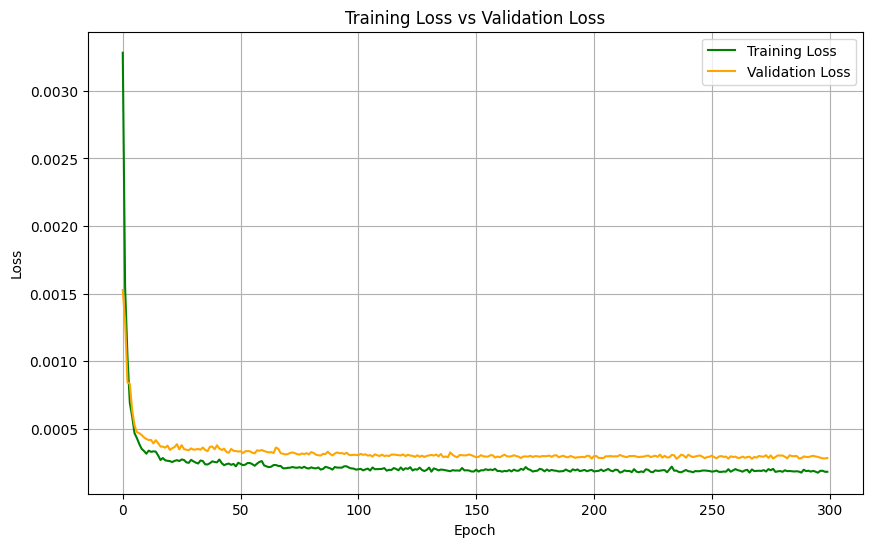

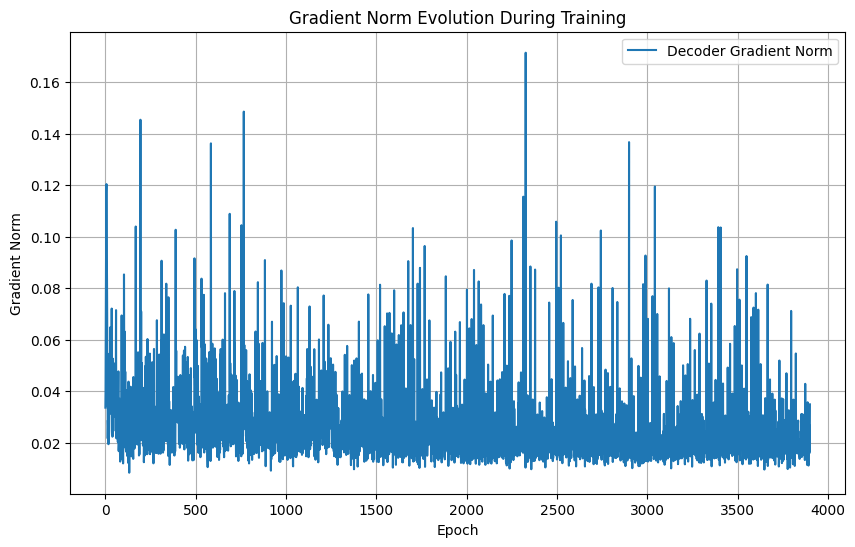

In [18]:
# Creazione del VAE con Decoder da allenare
decoder_layers_reversed = decoder_layers[::-1]
decoder = Decoder(decoder_layers_reversed)
vae_model = VAE(encoder,decoder)


# Configurazione Ottimizzatore e Scheduler

optimizer = optim.Adam(filter(lambda p: p.requires_grad, vae_model.parameters()), lr=decoder_config["learning_rate"])
scheduler_config = decoder_config.get("scheduler")
scheduler = get_scheduler(optimizer, scheduler_config)

# Allenamento del Decoder:
# Allenamento del modello
train_losses, val_losses, stopped_epoch, gradient_history, lr_evolution = reconstruct_y2fromy1(
    epochs=epochs,
    train_loader=train_loader,
    val_loader=val_loader,  # Aggiungi se hai un dataset di validazione
    model=vae_model,
    optimizer=optimizer,
    scheduler=scheduler,
    scheduler_config=scheduler_config,
    early_stopping_params=decoder_config["early_stopping"]
)

In [19]:
# Aggiungi la nuova configurazione al database (eventualmente sovrascrive)

add_config(decoder_config, decoder_name, decoder_database_path)

decoder_model_folder = "Decoder Models"
decoder_name += ".pth"


#Salva il modello allenato
save_decoder(decoder=decoder,decoder_layers=decoder_layers ,
            train_losses=train_losses, val_losses=val_losses,
            train_data=train_data, val_data=val_data, epoch=epochs, stopped_epoch=stopped_epoch, 
            gradient_history=gradient_history, lr_evolution=lr_evolution, 
            output_folder=decoder_model_folder, decoder_name = decoder_name)

Decoder and training info saved to Decoder Models/Prova15Decoder.pth
